# Phase 4 (notebook) — Restitution : KPIs et visualisations exhaustives

Remplace `phase4_reporting.py` **et** les tableaux de `rapport_analyse_sentiment.md`
qui tronquaient silencieusement les categories/canaux les plus rares. Chaque
graphique ci-dessous represente 100% des valeurs presentes dans les donnees.

In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
sys.path.insert(0, "..")

from viz_utils import plot_full_distribution, plot_stacked_share, plot_full_counts

PROJECT_DIR = Path("..").resolve()
PHASE3_CSV = PROJECT_DIR / "reclamations_phase3.csv"

plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(PHASE3_CSV, low_memory=False)
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["mois"] = df["created_at"].dt.to_period("M").astype(str)

def parse_montant(value) -> float:
    if pd.isna(value):
        return float("nan")
    digits = re.sub(r"[^\d]", "", str(value))
    return float(digits) if digits else float("nan")

df["montant_xaf"] = df["ticket_attributes_Montant en XAF"].map(parse_montant)
print(f"{len(df)} tickets charges depuis {PHASE3_CSV.name}")

8284 tickets charges depuis reclamations_phase3.csv


## 1. Sentiment global

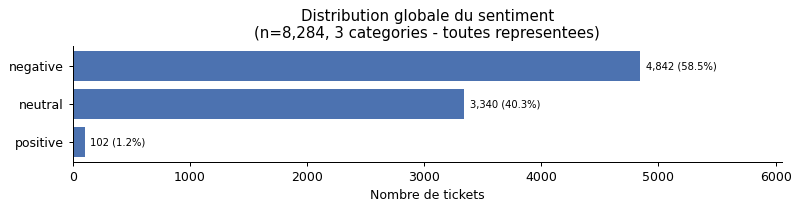

In [2]:
_ = plot_full_distribution(df["sentiment_label"], "Distribution globale du sentiment")
plt.show()

## 2. Sentiment par categorie — TOUTES les categories

Comparer avec `rapport_analyse_sentiment.md` section 4.2 : seules 10
categories y figuraient sur 15. Ici les 15 sont visibles, y compris les
categories a 2-17 tickets (`Feature request`, `Card issue`, `Internal task`,
`Bug report`, `Support Request`).

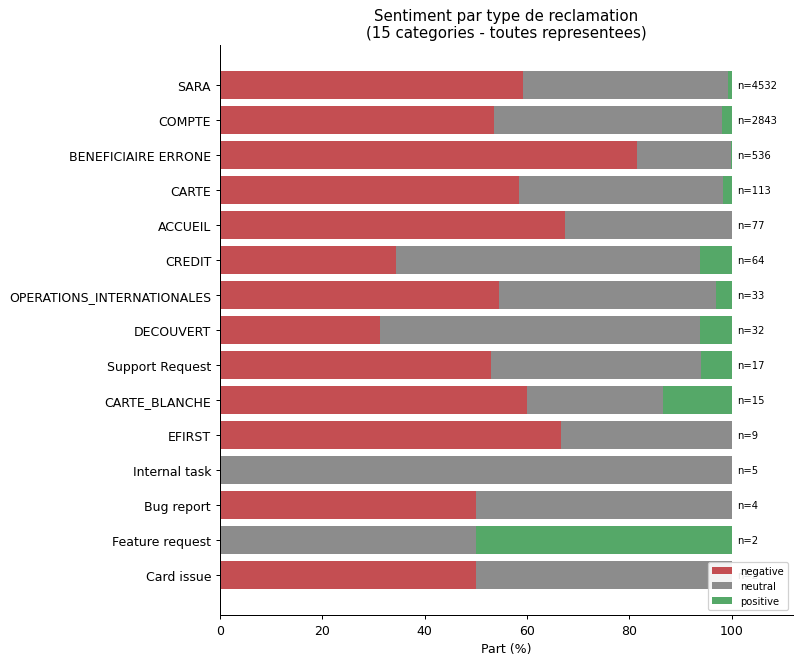

In [3]:
_ = plot_stacked_share(
    df, "ticket_type_name", "sentiment_label", "Sentiment par type de reclamation",
    colors={"negative": "#C44E52", "neutral": "#8C8C8C", "positive": "#55A868"},
)
plt.show()

## 3. Sentiment par canal — TOUS les canaux

`rapport_analyse_sentiment.md` section 4.3 s'arretait a 5 canaux sur 7
(`instagram` et `email` avaient disparu, malgre 1-2 tickets chacun).

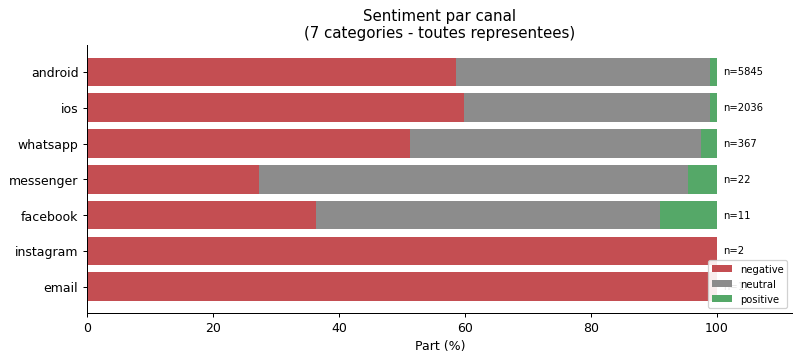

In [4]:
_ = plot_stacked_share(
    df, "channel", "sentiment_label", "Sentiment par canal",
    colors={"negative": "#C44E52", "neutral": "#8C8C8C", "positive": "#55A868"},
)
plt.show()

## 4. Evolution mensuelle

`rapport_analyse_sentiment.md` section 4.4 excluait les mois avant nov. 2025
(<25 tickets/mois) de la lecture de tendance. Ici, tous les mois restent
affiches ; le volume est indique sur chaque barre pour juger soi-meme de la
significativite plutot que de la voir disparaitre du graphique.

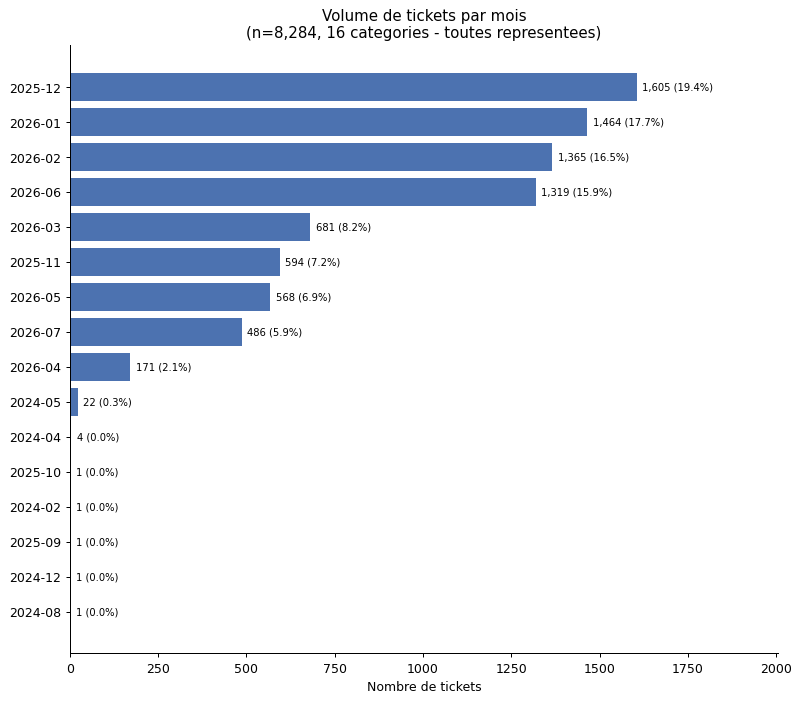

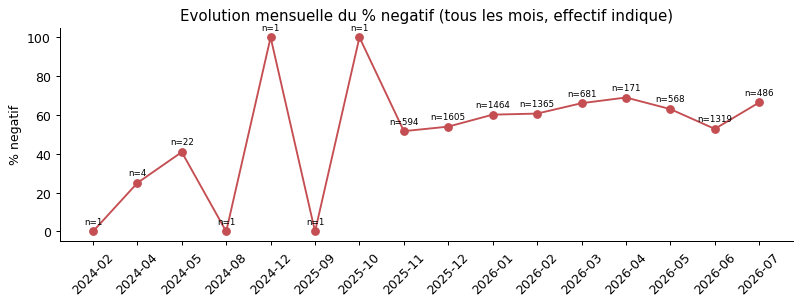

In [5]:
volume_mensuel = df["mois"].value_counts()
fig, ax = plot_full_counts(volume_mensuel.sort_index(ascending=False), "Volume de tickets par mois", xlabel="Nombre de tickets")
plt.show()

pct_negatif_mensuel = df.groupby("mois")["sentiment_label"].apply(lambda s: (s == "negative").mean() * 100)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(pct_negatif_mensuel.index, pct_negatif_mensuel.values, marker="o", color="#C44E52")
for x, y, n in zip(pct_negatif_mensuel.index, pct_negatif_mensuel.values, volume_mensuel.reindex(pct_negatif_mensuel.index)):
    ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(0, 6), fontsize=7, ha="center")
ax.set_ylabel("% negatif")
ax.set_title("Evolution mensuelle du % negatif (tous les mois, effectif indique)")
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

## 5. Montants en jeu (mediane, par categorie)

⚠️ Le montant *moyen* est fausse par des valeurs aberrantes extremes (jusqu'a
500 milliards XAF sur un seul ticket, cf. `01_exploration_toutes_colonnes.ipynb`
section 6). La mediane est utilisee ici, pour toutes les categories, y
compris celles avec tres peu de montants valides.

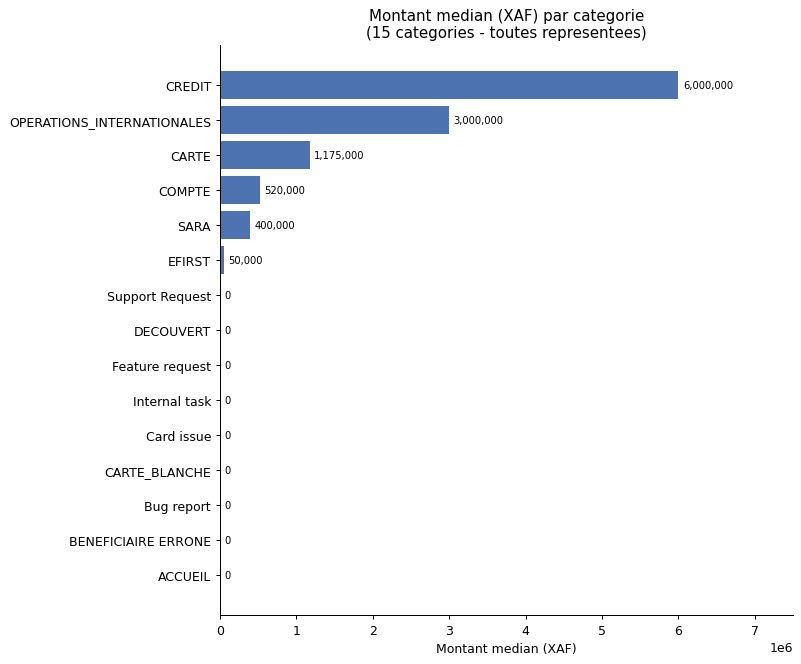

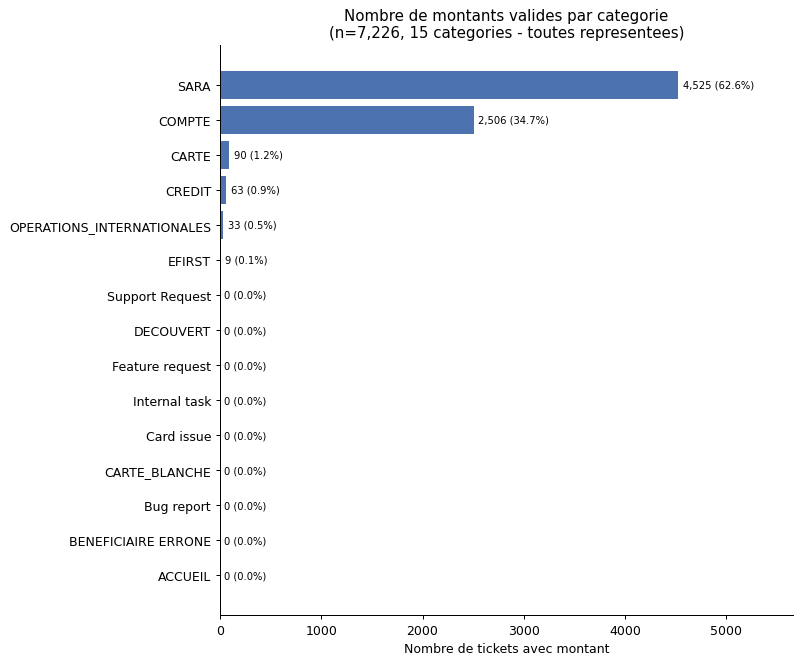

In [6]:
montant_median = df.groupby("ticket_type_name")["montant_xaf"].median().fillna(0)
fig, ax = plot_full_counts(montant_median, "Montant median (XAF) par categorie", xlabel="Montant median (XAF)", pct=False, value_fmt="{:,.0f}")
plt.show()

nb_montants_valides = df.groupby("ticket_type_name")["montant_xaf"].apply(lambda s: s.notna().sum())
fig, ax = plot_full_counts(nb_montants_valides, "Nombre de montants valides par categorie", xlabel="Nombre de tickets avec montant")
plt.show()

## 6. KPIs synthetiques

Resume chiffre en une cellule : volume, % negatif global, montant median,
taux de resolution, part de tickets avec texte libre.

In [7]:
pct_neg = (df["sentiment_label"] == "negative").mean() * 100
med_montant = df["montant_xaf"].median()
pct_resolved = df["ticket_state_category"].astype(str).str.lower().eq("resolved").mean() * 100
pct_texte = df["texte"].notna().mean() * 100 if "texte" in df.columns else float("nan")

print(f"Tickets analyses        : {len(df):,}")
print(f"% negatif global        : {pct_neg:.1f}%")
print(f"Montant median (XAF)    : {med_montant:,.0f}")
print(f"% resolus               : {pct_resolved:.1f}%")
print(f"% avec texte libre      : {pct_texte:.1f}%")

Tickets analyses        : 8,284
% negatif global        : 58.5%
Montant median (XAF)    : 500,000
% resolus               : 12.6%
% avec texte libre      : 100.0%


## 7. Volume et % negatif par categorie x mois (heatmaps)

Heatmaps annotees (la valeur est ecrite dans chaque cellule, donc les petits
effectifs restent lisibles) : ou se concentre le volume, et ou le sentiment
se degrade dans le temps.

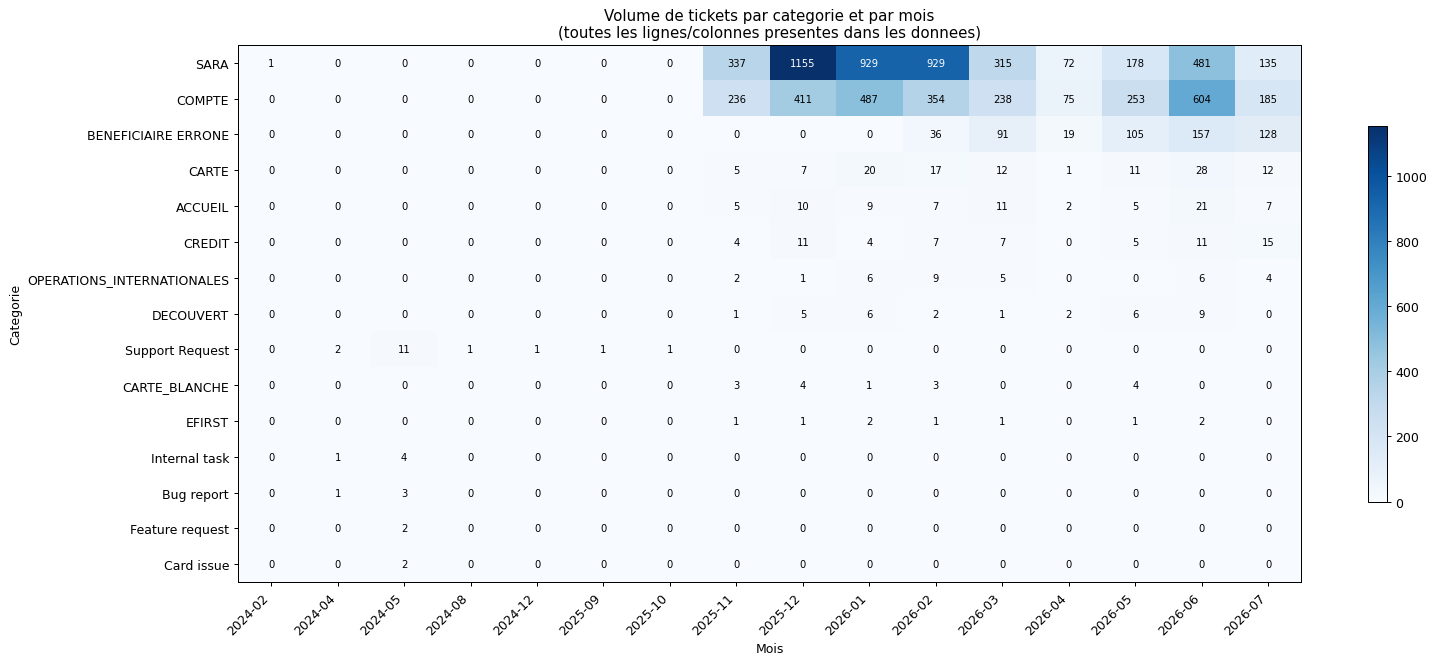

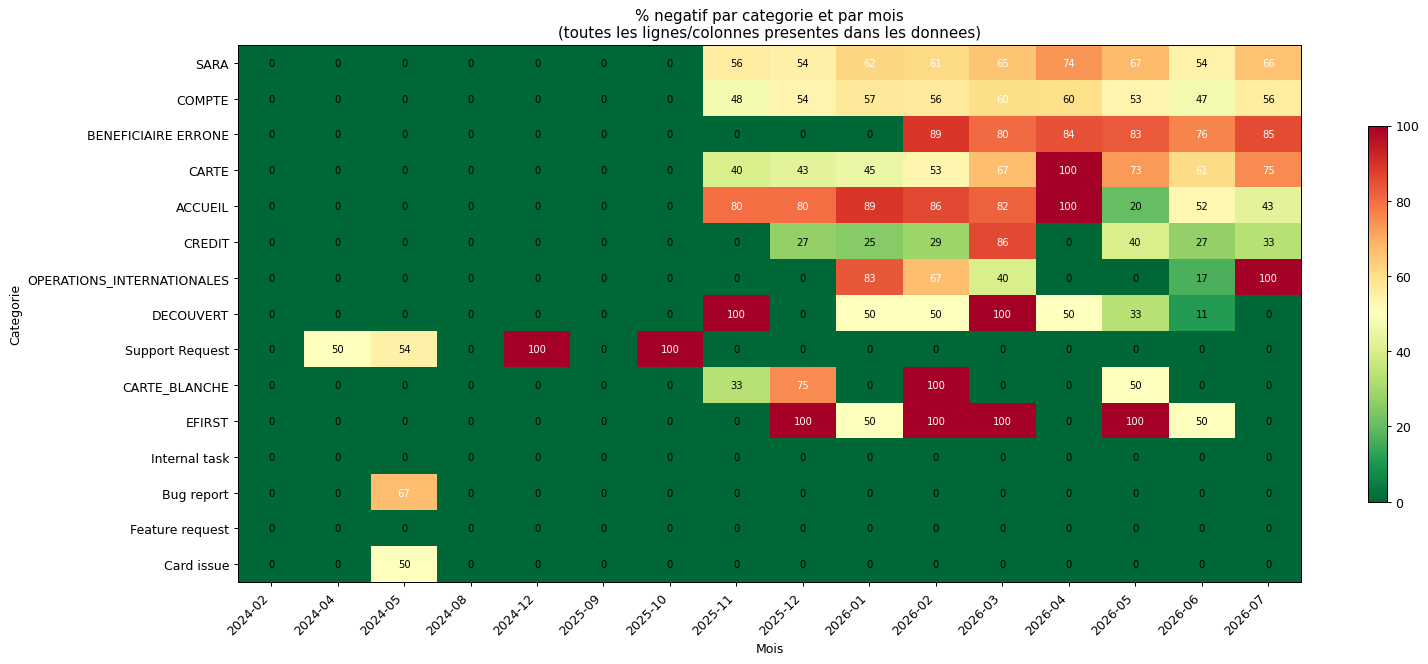

In [8]:
from viz_utils import annotated_heatmap

valid = df["created_at"].notna()
volume_matrix = pd.crosstab(df.loc[valid, "ticket_type_name"], df.loc[valid, "mois"])
volume_matrix = volume_matrix.loc[volume_matrix.sum(axis=1).sort_values(ascending=False).index]
fig, ax = annotated_heatmap(
    volume_matrix, "Volume de tickets par categorie et par mois",
    fmt=".0f", cmap="Blues", xlabel="Mois", ylabel="Categorie",
)
plt.show()

neg = (df["sentiment_label"] == "negative").astype(float) * 100
pct_matrix = neg[valid].groupby(
    [df.loc[valid, "ticket_type_name"], df.loc[valid, "mois"]]
).mean().unstack().fillna(0).round(1)
pct_matrix = pct_matrix.reindex(volume_matrix.index)
fig, ax = annotated_heatmap(
    pct_matrix, "% negatif par categorie et par mois",
    fmt=".0f", cmap="RdYlGn_r", xlabel="Mois", ylabel="Categorie",
)
plt.show()

## 8. Etat des tickets par categorie (taux de resolution)

`ticket_state_category` comme proxy du traitement : quelles categories
restent le plus en attente ? (Rappel du rapport initial : 93% des tickets
sont "submitted" - le taux de resolution est un signal faible mais a suivre.)

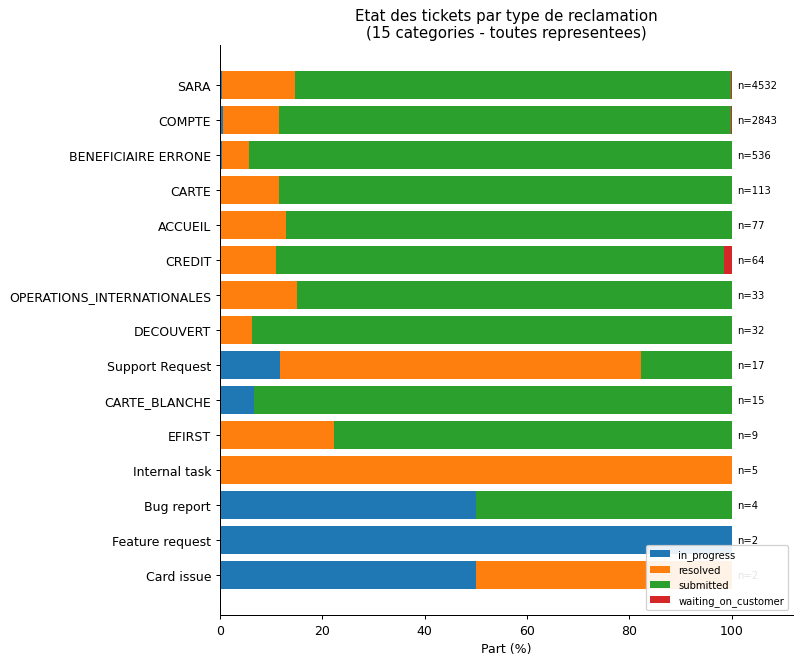

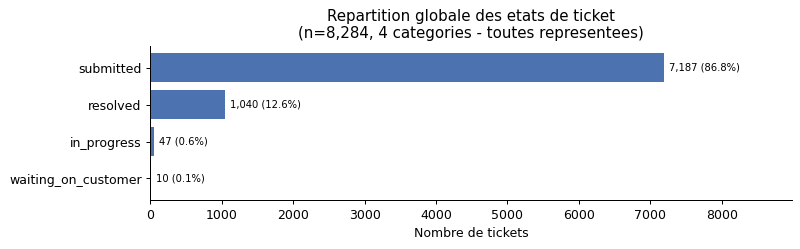

In [9]:
_ = plot_stacked_share(
    df, "ticket_type_name", "ticket_state_category",
    "Etat des tickets par type de reclamation",
)
plt.show()

_ = plot_full_distribution(df["ticket_state_category"], "Repartition globale des etats de ticket")
plt.show()

## 9. Topics x sentiment — TOUS les topics (pas de top 10)

`rapport_analyse_sentiment.md` section 4.6 ne montrait que les 10 sous-motifs
les plus critiques (volume >= 15, tries par %negatif). Ici, les 34 topics
sont tous representes, tries par %negatif, avec le volume en annotation.

34 topics representes (100% des topics decouverts en Phase 3).


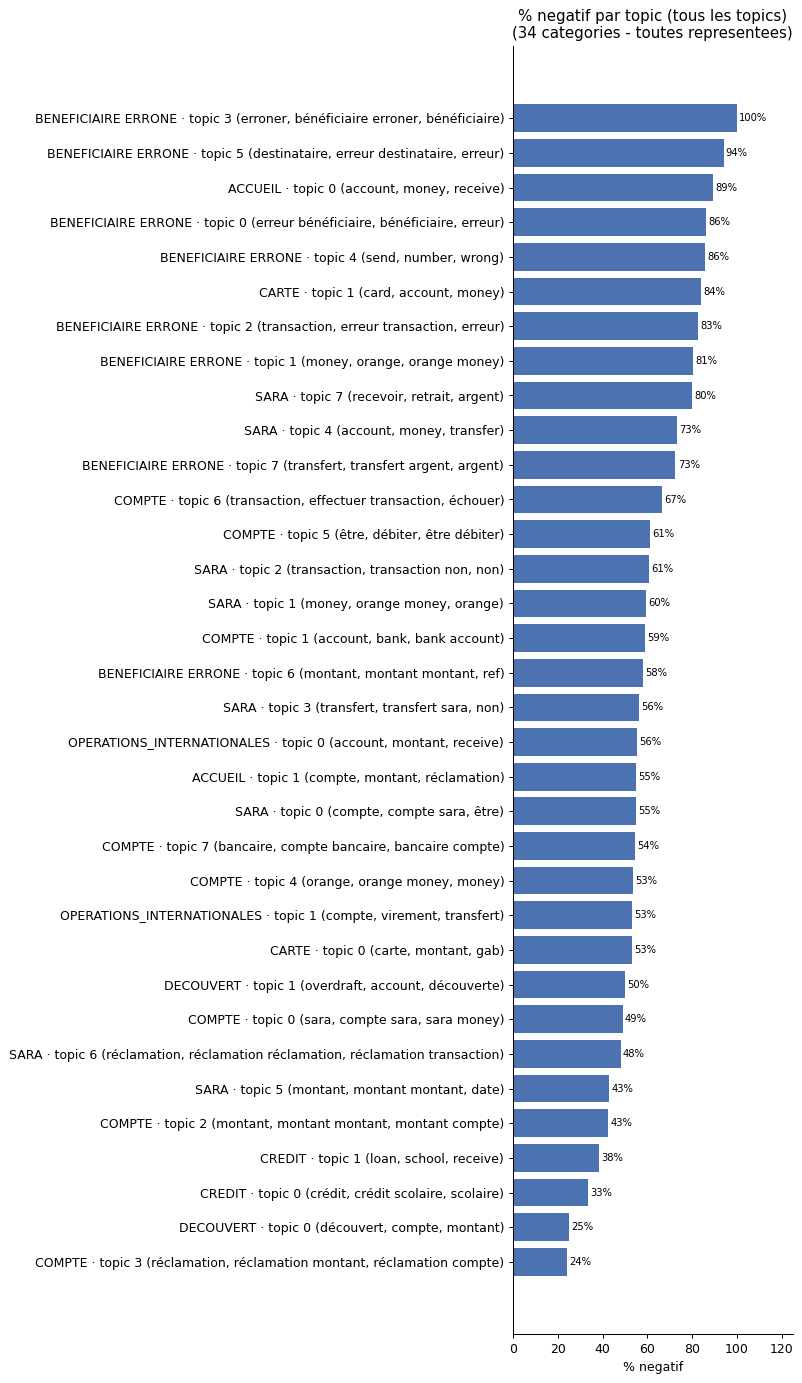

In [10]:
topic_mask = df["topic_id"] >= 0
kpi_topics = (
    df.loc[topic_mask]
    .groupby(["ticket_type_name", "topic_id", "topic_keywords"])
    .agg(nb_tickets=("sentiment_label", "size"), pct_negatif=("sentiment_label", lambda s: (s == "negative").mean() * 100))
    .reset_index()
)
kpi_topics["label"] = (
    kpi_topics["ticket_type_name"] + " · topic " + kpi_topics["topic_id"].astype(str)
    + " (" + kpi_topics["topic_keywords"].str.split(", ").str[:3].str.join(", ") + ")"
)
pct_series = kpi_topics.set_index("label")["pct_negatif"]
fig, ax = plot_full_counts(pct_series, "% negatif par topic (tous les topics)", xlabel="% negatif", pct=False, value_fmt="{:.0f}%")
plt.show()

print(f"{len(kpi_topics)} topics representes (100% des topics decouverts en Phase 3).")
kpi_topics.sort_values(["pct_negatif", "nb_tickets"], ascending=[False, False])[["ticket_type_name", "topic_id", "topic_keywords", "nb_tickets", "pct_negatif"]]

## 10. Verification — couverture vs l'ancien rapport

In [11]:
n_cat_rapport_precedent = 10
n_canal_rapport_precedent = 5
n_topics_rapport_precedent = 10

print(f"Categories : {df['ticket_type_name'].nunique()} representees ici, contre {n_cat_rapport_precedent} dans l'ancien rapport.")
print(f"Canaux     : {df['channel'].nunique()} representes ici, contre {n_canal_rapport_precedent} dans l'ancien rapport.")
print(f"Topics     : {len(kpi_topics)} representes ici, contre {n_topics_rapport_precedent} dans l'ancien rapport.")
print(f"Mois       : {df['mois'].nunique()} representes ici (l'ancien rapport en excluait certains sous 25 tickets/mois).")

Categories : 15 representees ici, contre 10 dans l'ancien rapport.
Canaux     : 7 representes ici, contre 5 dans l'ancien rapport.
Topics     : 34 representes ici, contre 10 dans l'ancien rapport.
Mois       : 16 representes ici (l'ancien rapport en excluait certains sous 25 tickets/mois).
